### Análisis de Datos

In [1]:
import pandas as pd
import numpy as np

In [4]:
casas_dev_df = pd.read_csv("casas_dev.csv")
casas_test_df = pd.read_csv("casas_test.csv")

In [ ]:
print(casas_dev_df.head(7))
print('shape = ', casas_dev_df.shape)

     area area_units  is_house  has_pool   age  price        lat        lon  \
0   635.0       sqft         1         0  18.0  546.0  40.679064 -74.007844   
1  1098.0       sqft         0         0   9.0  759.0  40.712839 -73.967750   
2   667.0       sqft         0         0   7.0  464.0  40.669863 -74.029414   
3   127.0         m2         1         1  16.0  251.0 -34.600437 -58.415266   
4  1378.0       sqft         0         0   8.0  963.0  40.722322 -73.983229   
5    92.0         m2         1         0   6.0  182.0 -34.640570 -58.365384   
6   786.0       sqft         0         0  11.0  530.0  40.691765 -74.003382   

   rooms  
0    2.0  
1    3.0  
2    2.0  
3    4.0  
4    4.0  
5    3.0  
6    2.0  
shape =  (900, 9)


In [11]:
print(casas_dev_df.isnull().sum())

area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64


In [ ]:
# Contar cuántos valores NaN hay en la columna "age"
n_nan_age = casas_dev_df["age"].isna().sum()
total_filas = len(casas_dev_df)  # Total de filas en el dataset
porcentaje_nan_age = (n_nan_age / total_filas) * 100

print(f"Valores NaN en 'age': {n_nan_age} sobre un total de {total_filas} filas ({porcentaje_nan_age:.2f}%)")

# Contar NaNs en todo el dataset
print("\nValores faltantes por columna:")
print(casas_dev_df.isna().sum())


Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)

Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64


: 

In [ ]:

# Resumen estadístico de cada dataset
print("\nResumen estadístico de casas_dev:")
print(casas_dev_df.describe())
print("\nResumen estadístico de casas_test:")
print(casas_test_df.describe())


Resumen estadístico de casas_dev:
              area    is_house    has_pool         age        price  \
count   900.000000  900.000000  900.000000  770.000000   900.000000   
mean    533.598889    0.418889    0.144444   10.212987   466.197778   
std     502.318230    0.493651    0.351735    4.773010   347.122903   
min      40.000000    0.000000    0.000000    1.000000    65.000000   
25%      93.000000    0.000000    0.000000    6.250000   178.750000   
50%     164.500000    0.000000    0.000000   11.000000   323.500000   
75%     980.000000    1.000000    0.000000   14.000000   712.500000   
max    2164.000000    1.000000    1.000000   20.000000  1992.000000   

              lat         lon       rooms  
count  900.000000  900.000000  828.000000  
mean     1.966225  -65.967203    2.737923  
std     37.661269    7.813671    0.948574  
min    -34.686302  -74.058238    1.000000  
25%    -34.605803  -74.005566    2.000000  
50%    -34.529704  -58.459293    3.000000  
75%     40.709819

In [ ]:


# Identificar valores faltantes
def check_missing_values(df, name):
    missing = df.isnull().sum()
    print(f"\nValores faltantes en {name}:")
    print(missing[missing > 0])

check_missing_values(casas_dev_df, "casas_dev")
check_missing_values(casas_test_df, "casas_test")



Valores faltantes en casas_dev:
age      130
rooms     72
dtype: int64

Valores faltantes en casas_test:
age      16
rooms     4
dtype: int64


In [ ]:

# Comparar distribuciones entre ambos conjuntos
def compare_distributions(df1, df2, name1, name2):
    for column in df1.select_dtypes(include=[np.number]).columns:
        print(f"\nComparando la media de {column}:")
        print(f"{name1}: {df1[column].mean()} vs {name2}: {df2[column].mean()}")

compare_distributions(casas_dev_df, casas_test_df, "casas_dev", "casas_test")


Comparando la media de area:
casas_dev: 533.5988888888888 vs casas_test: 498.52

Comparando la media de is_house:
casas_dev: 0.41888888888888887 vs casas_test: 0.38

Comparando la media de has_pool:
casas_dev: 0.14444444444444443 vs casas_test: 0.15

Comparando la media de age:
casas_dev: 10.212987012987012 vs casas_test: 9.952380952380953

Comparando la media de price:
casas_dev: 466.1977777777778 vs casas_test: 437.56

Comparando la media de lat:
casas_dev: 1.9662253892784876 vs casas_test: 0.7949671001769122

Comparando la media de lon:
casas_dev: -65.96720266424107 vs casas_test: -65.72874324833161

Comparando la media de rooms:
casas_dev: 2.7379227053140096 vs casas_test: 2.6770833333333335


Acomodar nulls

In [ ]:
casas_dev_df["age"].fillna(casas_dev_df["age"].median(), inplace=True)
casas_test_df["age"].fillna(casas_test_df["age"].median(), inplace=True)



In [ ]:
casas_dev_df["rooms"].fillna(casas_dev_df["rooms"].mode()[0], inplace=True)

casas_test_df["rooms"].fillna(casas_test_df["rooms"].mode()[0], inplace=True)


In [ ]:
# Detectar valores atípicos (outliers) usando el rango intercuartil (IQR)
def detect_outliers(df, name):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
    print(f"\nValores atípicos detectados en {name}:")
    print(outliers[outliers > 0])

# Aplicar la detección de outliers
detect_outliers(casas_dev_df, "casas_dev")
detect_outliers(casas_test_df, "casas_test")


TypeError: unsupported operand type(s) for -: 'str' and 'str'

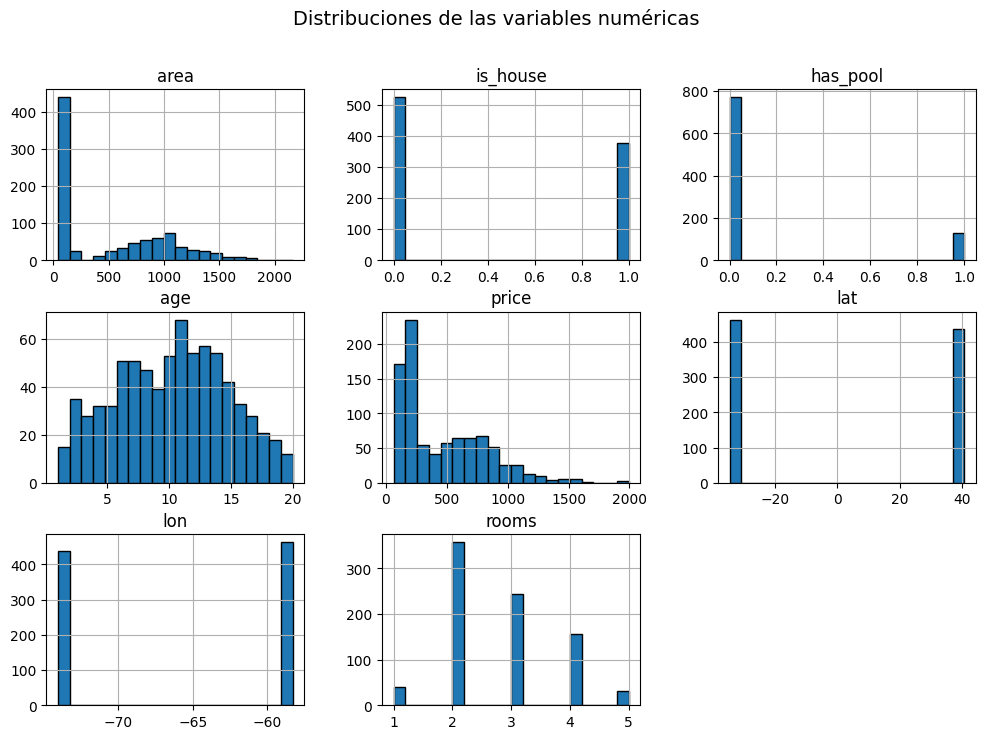

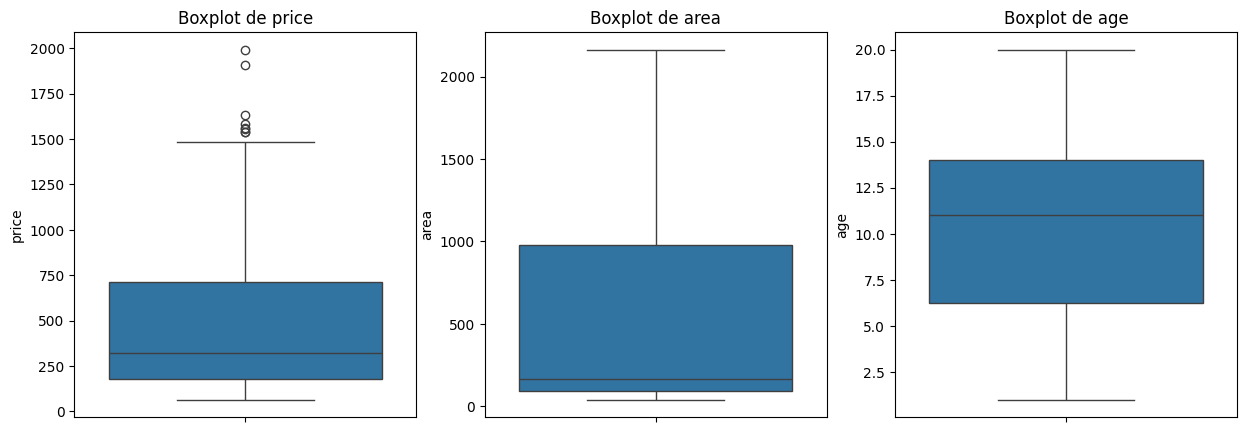

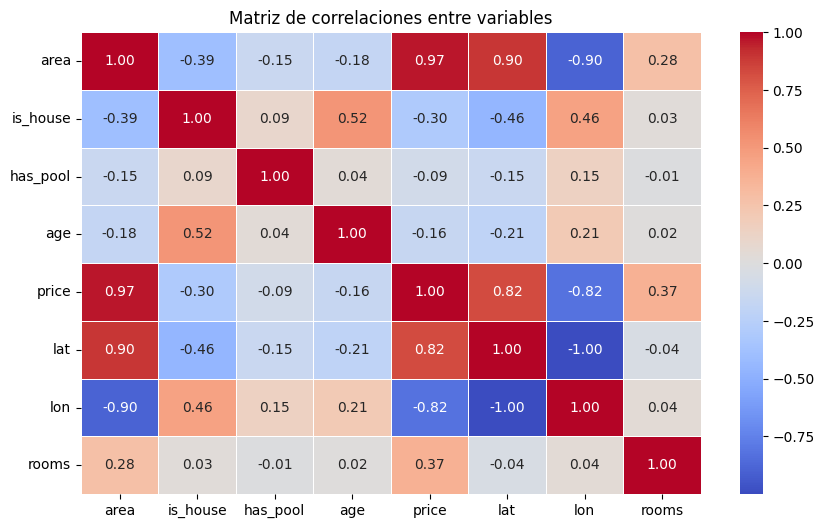

Resumen estadístico:
               area    is_house    has_pool         age        price  \
count   900.000000  900.000000  900.000000  770.000000   900.000000   
mean    533.598889    0.418889    0.144444   10.212987   466.197778   
std     502.318230    0.493651    0.351735    4.773010   347.122903   
min      40.000000    0.000000    0.000000    1.000000    65.000000   
25%      93.000000    0.000000    0.000000    6.250000   178.750000   
50%     164.500000    0.000000    0.000000   11.000000   323.500000   
75%     980.000000    1.000000    0.000000   14.000000   712.500000   
max    2164.000000    1.000000    1.000000   20.000000  1992.000000   

              lat         lon       rooms  
count  900.000000  900.000000  828.000000  
mean     1.966225  -65.967203    2.737923  
std     37.661269    7.813671    0.948574  
min    -34.686302  -74.058238    1.000000  
25%    -34.605803  -74.005566    2.000000  
50%    -34.529704  -58.459293    3.000000  
75%     40.709819  -58.379873 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cargar datos (reemplazar con el dataset real)
casas_dev_df = pd.read_csv("casas_dev.csv")

# Resumen estadístico
stats_summary = casas_dev_df.describe()

# 1. Histograma de todas las variables numéricas
casas_dev_df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Distribuciones de las variables numéricas", fontsize=14)
plt.show()

# 2. Boxplots para detectar valores atípicos en 'price', 'area' y 'age'
plt.figure(figsize=(15, 5))

for i, col in enumerate(["price", "area", "age"], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=casas_dev_df[col])
    plt.title(f"Boxplot de {col}")

plt.show()

# 3. Heatmap de correlación entre variables
plt.figure(figsize=(10, 6))
sns.heatmap(casas_dev_df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones entre variables")
plt.show()

# Imprimir el resumen estadístico
print("Resumen estadístico:\n", stats_summary)


C:\Users\anapt\AppData\Local\Temp\ipykernel_22500\2081162698.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\anapt\AppData\Local\Temp\ipykernel_22500\2081162698.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

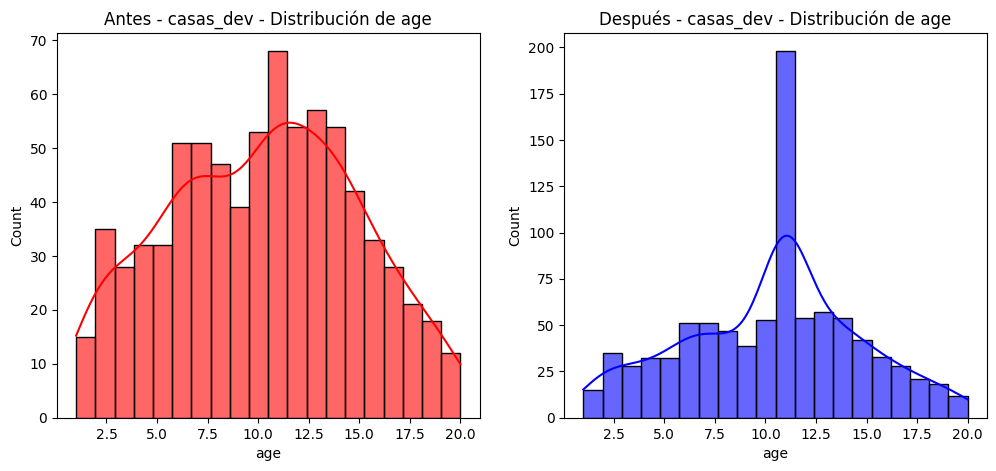

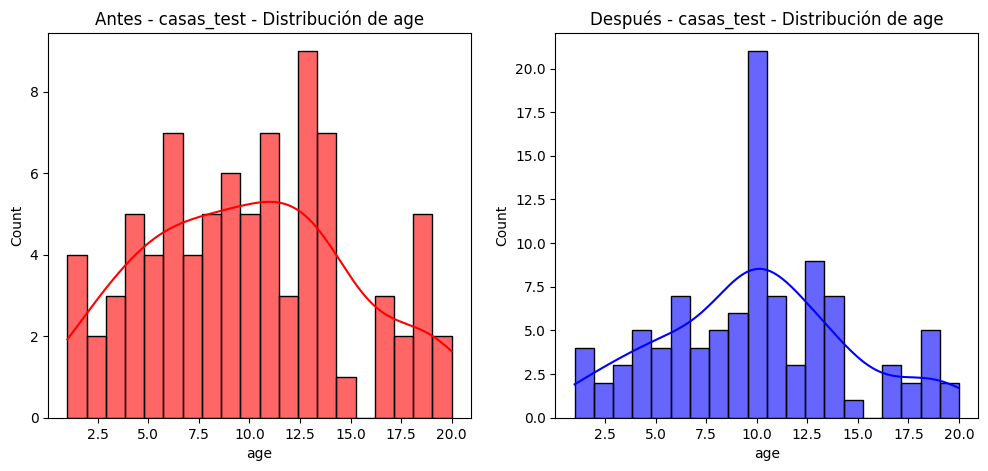

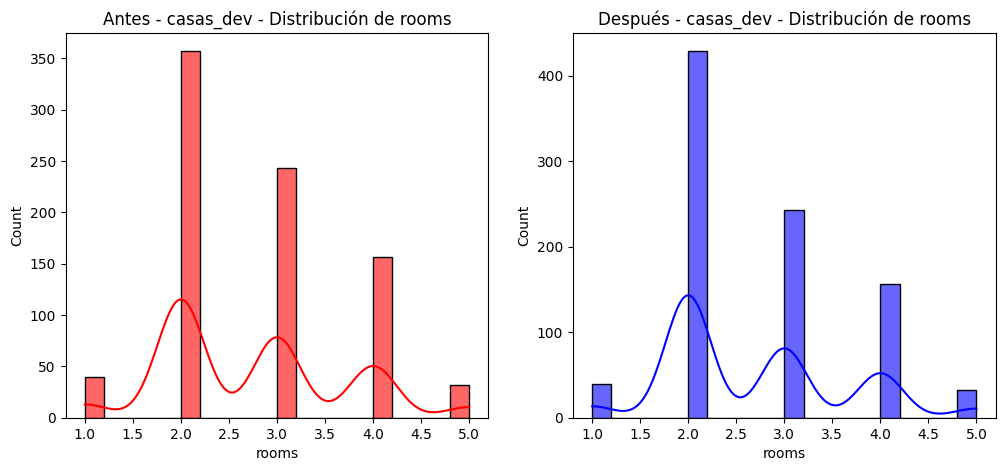

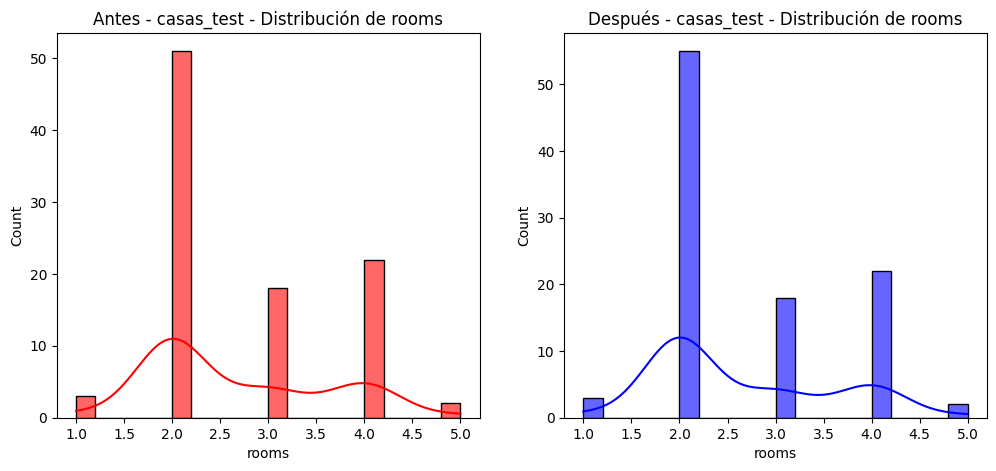

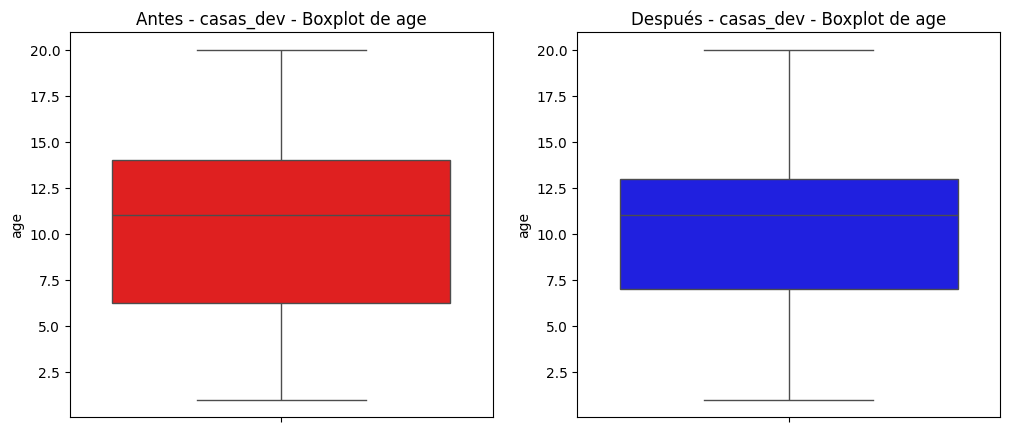

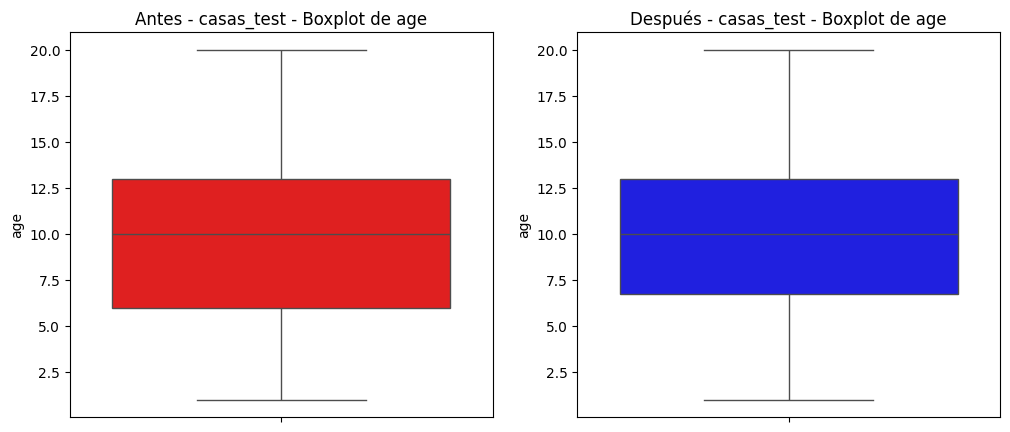

Resumen estadístico antes de tratar los NaNs - casas_dev:
               age       rooms
count  770.000000  828.000000
mean    10.212987    2.737923
std      4.773010    0.948574
min      1.000000    1.000000
25%      6.250000    2.000000
50%     11.000000    3.000000
75%     14.000000    3.000000
max     20.000000    5.000000

Resumen estadístico después de tratar los NaNs - casas_dev:
               age       rooms
count  900.000000  900.000000
mean    10.326667    2.678889
std      4.423112    0.931586
min      1.000000    1.000000
25%      7.000000    2.000000
50%     11.000000    2.000000
75%     13.000000    3.000000
max     20.000000    5.000000

Resumen estadístico antes de tratar los NaNs - casas_test:
              age      rooms
count  84.000000  96.000000
mean    9.952381   2.677083
std     5.112953   0.934652
min     1.000000   1.000000
25%     6.000000   2.000000
50%    10.000000   2.000000
75%    13.000000   3.250000
max    20.000000   5.000000

Resumen estadístico despu

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cargar datos
casas_dev_df = pd.read_csv("casas_dev.csv")
casas_test_df = pd.read_csv("casas_test.csv")

# Guardar copias antes de modificar los NaNs
casas_dev_original = casas_dev_df.copy()
casas_test_original = casas_test_df.copy()

# Estrategia para manejar NaNs:
# - En 'age', rellenamos con la mediana del conjunto respectivo
# - En 'rooms', rellenamos con la moda del conjunto respectivo
for df, name in zip([casas_dev_df, casas_test_df], ["casas_dev", "casas_test"]):
    df['age'].fillna(df['age'].median(), inplace=True)
    df['rooms'].fillna(df['rooms'].mode()[0], inplace=True)

# Función para graficar histogramas antes y después del tratamiento de NaNs
def plot_histograms(original, modified, column, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.histplot(original[column], bins=20, kde=True, ax=axes[0], color="red", alpha=0.6)
    axes[0].set_title(f"Antes - {dataset_name} - Distribución de {column}")
    
    sns.histplot(modified[column], bins=20, kde=True, ax=axes[1], color="blue", alpha=0.6)
    axes[1].set_title(f"Después - {dataset_name} - Distribución de {column}")
    
    plt.show()

# Graficar para 'age' y 'rooms' en ambos datasets
for col in ["age", "rooms"]:
    for original, modified, name in zip([casas_dev_original, casas_test_original], 
                                        [casas_dev_df, casas_test_df], 
                                        ["casas_dev", "casas_test"]):
        plot_histograms(original, modified, col, name)

# Función para graficar boxplots antes y después
def plot_boxplots(original, modified, column, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.boxplot(y=original[column], ax=axes[0], color="red")
    axes[0].set_title(f"Antes - {dataset_name} - Boxplot de {column}")

    sns.boxplot(y=modified[column], ax=axes[1], color="blue")
    axes[1].set_title(f"Después - {dataset_name} - Boxplot de {column}")
    
    plt.show()

# Graficar boxplots para 'age' en ambos datasets
for original, modified, name in zip([casas_dev_original, casas_test_original], 
                                    [casas_dev_df, casas_test_df], 
                                    ["casas_dev", "casas_test"]):
    plot_boxplots(original, modified, "age", name)

# Comparar estadísticas antes y después
summary_before_dev = casas_dev_original[["age", "rooms"]].describe()
summary_after_dev = casas_dev_df[["age", "rooms"]].describe()

summary_before_test = casas_test_original[["age", "rooms"]].describe()
summary_after_test = casas_test_df[["age", "rooms"]].describe()

print("Resumen estadístico antes de tratar los NaNs - casas_dev:\n", summary_before_dev)
print("\nResumen estadístico después de tratar los NaNs - casas_dev:\n", summary_after_dev)

print("\nResumen estadístico antes de tratar los NaNs - casas_test:\n", summary_before_test)
print("\nResumen estadístico después de tratar los NaNs - casas_test:\n", summary_after_test)


poner la mediana me arruina la normal

tengo que ver cómo hacer feature engineering sin asumir relaciones entre las features que no sean reales y me arruienen el entrenamiento.
